# **1. Perkenalan Dataset**

## **Dicoding Final Project — Sistem Machine Learning (MSML)**
* **Nama Praktikan / Pengembang:** Naufal Arkaan
* **Topik Project:** End-to-End MLOps Pipeline untuk Prediksi Deposito Berjangka (Bank Marketing)
* **Dataset:** Bank Marketing Dataset (`bank-full.csv`)
* **Sumber Dataset:** UCI Machine Learning Repository / Direct Public Dataset
* **Task Machine Learning:** Binary Classification (Klasifikasi Biner)
* **Target Variable:** `y` (`yes` = Nasabah berlangganan deposito berjangka, `no` = Nasabah tidak berlangganan)

---

### **Latar Belakang & Problem Statement:**
Sektor perbankan menghadapi tantangan dalam meningkatkan efisiensi kampanye pemasaran produk perbankan, khususnya deposito berjangka (*term deposit*). Kampanye langsung (*telemarketing*) memerlukan biaya dan waktu yang signifikan bagi tim sales/marketing. 

Jika bank menghubungi seluruh nasabah secara acak, tingkat konversi cenderung rendah dan berpotensi mengganggu nasabah yang tidak tertarik. Oleh karena itu, diperlukan model prediktif machine learning yang dapat memprediksi secara akurat apakah seorang nasabah memiliki kecenderungan tinggi untuk menyetujui penawaran deposito berjangka berdasarkan profil demografis, riwayat finansial, dan interaksi kampanye sebelumnya.

### **Karakteristik Dataset:**
* **Jumlah Observasi:** 45.211 baris data.
* **Jumlah Fitur:** 16 fitur prediktor (terdiri dari 7 fitur numerik dan 9 fitur kategorikal) + 1 kolom target `y`.
* **Karakteristik Khusus:**
  1. **Imbalanced Target:** Distribusi target sangat tidak seimbang (~88% `no` dan ~12% `yes`). Metrik evaluasi tidak boleh bertumpu hanya pada *Accuracy*, melainkan memerlukan *F1-Score*, *Precision*, *Recall*, dan *ROC-AUC*.
  2. **Nilai Unknown:** Sejumlah kolom kategorikal memiliki nilai `"unknown"` yang perlu dianalisis dan ditangani secara tepat.
  3. **Pertimbangan Data Leakage (Kolom `duration`):** Durasi panggilan telepon memiliki korelasi yang sangat tinggi terhadap target, namun durasi panggilan baru diketahui *setelah* panggilan selesai (tidak realistis diketahui sebelum panggilan dilakukan). Oleh karena itu, aspek ini dianalisis secara mendalam pada bagian EDA dan Preprocessing.


# **2. Import Library**

Pada tahap ini, kita mengimpor seluruh pustaka Python yang dibutuhkan untuk analisis data eksploratif (EDA), visualisasi, serta tahapan data preprocessing.


In [1]:
import os
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder, OneHotEncoder

# Pengaturan visualisasi & peringatan
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
sns.set_palette('crest')
%matplotlib inline

print("Pustaka berhasil diimpor dengan sukses!")
print(f"Versi Pandas: {pd.__version__}")
print(f"Versi NumPy: {np.__version__}")


Pustaka berhasil diimpor dengan sukses!
Versi Pandas: 2.3.3
Versi NumPy: 2.5.3


# **3. Memuat Dataset**

Dataset `bank-full.csv` menggunakan delimiter titik koma (`;`). Kita memuat data dari file lokal dan memvalidasi struktur awal.


In [2]:
# Menentukan path dataset (fleksibel untuk dieksekusi dari root maupun subfolder preprocessing)
possible_paths = [
    "bank-full.csv",
    "dataset/bank-full.csv",
    "../dataset/bank-full.csv",
    "../bank-full.csv"
]

data_path = None
for path in possible_paths:
    if os.path.exists(path):
        data_path = path
        break

if data_path is None:
    raise FileNotFoundError("Dataset bank-full.csv tidak ditemukan di direktori yang dicari.")

print(f"Memuat dataset dari path: {data_path}")
df_raw = pd.read_csv(data_path, sep=';')

# Menampilkan 5 baris pertama dataset
df_raw.head()


Memuat dataset dari path: bank-full.csv


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [3]:
# Memeriksa dimensi data
print(f"Dimensi Dataset: {df_raw.shape[0]} baris, {df_raw.shape[1]} kolom")
print("-" * 50)

# Memeriksa informasi tipe data setiap kolom
df_raw.info()


Dimensi Dataset: 45211 baris, 17 kolom
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [4]:
# Memeriksa ringkasan statistik deskriptif fitur numerik
df_raw.describe().T


,count,mean,std,min,25%,50%,75%,max
age,45211.0,40.936210,10.618762,18.0,33.0,39.0,48.0,95.0
balance,45211.0,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0
day,45211.0,15.806419,8.322476,1.0,8.0,16.0,21.0,31.0
duration,45211.0,258.163080,257.527812,0.0,103.0,180.0,319.0,4918.0
campaign,45211.0,2.763841,3.098021,1.0,1.0,2.0,3.0,63.0
pdays,45211.0,40.197828,100.128746,-1.0,-1.0,-1.0,-1.0,871.0
previous,45211.0,0.580323,2.303441,0.0,0.0,0.0,0.0,275.0


In [5]:
# Memeriksa ringkasan deskriptif fitur kategorikal
df_raw.describe(include=['object']).T


,count,unique,top,freq
job,45211,12,blue-collar,9732
marital,45211,3,married,27214
education,45211,4,secondary,23202
default,45211,2,no,44396
housing,45211,2,yes,25130
loan,45211,2,no,37967
contact,45211,3,cellular,29285
month,45211,12,may,13766
poutcome,45211,4,unknown,36959
y,45211,2,no,39922


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, kita melakukan Exploratory Data Analysis (EDA) komprehensif untuk memahami karakteristik data, mendeteksi anomali/missing value, menganalisis distribusi target, korelasi fitur, dan menganalisis potensi data leakage.


### **4.1 Analisis Kualitas Data (Missing Values, Nilai 'unknown', dan Duplikasi)**


In [6]:
# 1. Pengecekan Missing Values (NaN) eksplisit
null_counts = df_raw.isnull().sum()
print("Jumlah Missing Values (NaN) per kolom:")
print(null_counts[null_counts > 0] if null_counts.sum() > 0 else "Tidak ada nilai NaN eksplisit pada dataset.")

# 2. Pengecekan Duplikasi Data
duplicate_count = df_raw.duplicated().sum()
print(f"\nJumlah Baris Duplikat: {duplicate_count} baris ({(duplicate_count/len(df_raw))*100:.2f}%)")

# 3. Pengecekan Nilai 'unknown' pada Fitur Kategorikal
unknown_dict = {}
for col in df_raw.select_dtypes(include='object').columns:
    count_unknown = (df_raw[col] == 'unknown').sum()
    if count_unknown > 0:
        unknown_dict[col] = {
            'Jumlah Unknown': count_unknown,
            'Persentase (%)': round((count_unknown / len(df_raw)) * 100, 2)
        }

df_unknown = pd.DataFrame(unknown_dict).T
print("\nKolom dengan nilai 'unknown':")
display(df_unknown)


Jumlah Missing Values (NaN) per kolom:
Tidak ada nilai NaN eksplisit pada dataset.

Jumlah Baris Duplikat: 0 baris (0.00%)



Kolom dengan nilai 'unknown':


,Jumlah Unknown,Persentase (%)
job,288.0,0.64
education,1857.0,4.11
contact,13020.0,28.80
poutcome,36959.0,81.75


**Interpretasi Kualitas Data:**
* Tidak ditemukan nilai `NaN` secara eksplisit, namun nilai hilang terselubung sebagai kategori `"unknown"`.
* Kolom `job` memiliki 288 (0,64%) nilai unknown dan `education` memiliki 1.857 (4,11%) nilai unknown — persentase ini relatif kecil sehingga dapat diimputasi dengan modus kategori yang paling dominan.
* Kolom `contact` (28,80%) dan `poutcome` (81,75%) memiliki proporsi unknown yang signifikan. Nilai `"unknown"` pada `poutcome` memiliki makna domain bahwa nasabah belum pernah dihubungi pada kampanye pemasaran sebelumnya (`previous == 0`), sehingga kategori ini tetap dipertahankan sebagai representasi informasi riil nasabah baru.


### **4.2 Analisis Distribusi Target (`y`)**


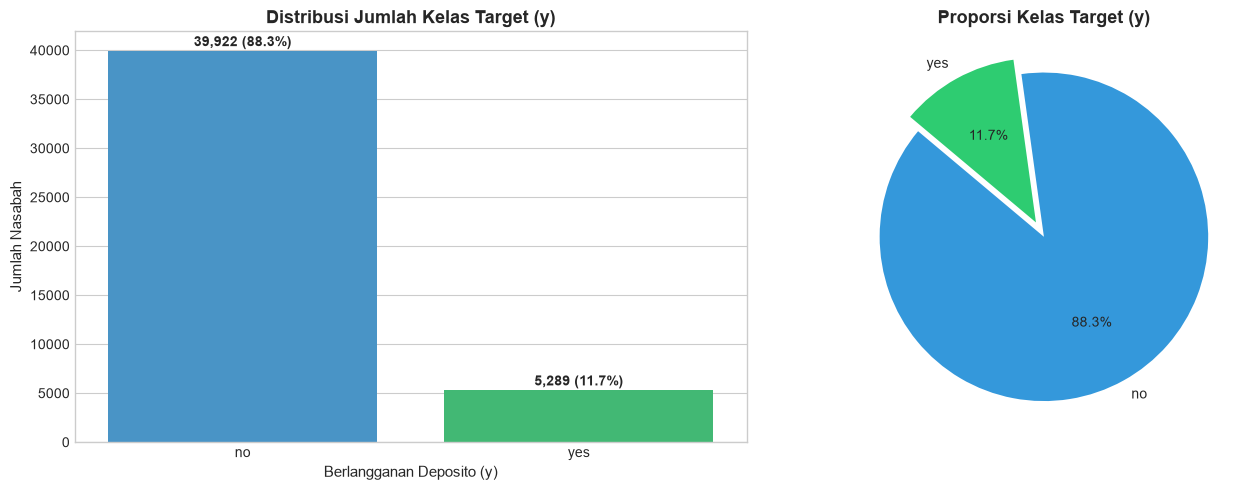

Kelas 'no' : 39,922 nasabah (88.30%)
Kelas 'yes': 5,289 nasabah (11.70%)


In [7]:
target_counts = df_raw['y'].value_counts()
target_percent = df_raw['y'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Bar Chart
sns.barplot(x=target_counts.index, y=target_counts.values, ax=axes[0], palette=['#3498db', '#2ecc71'])
axes[0].set_title('Distribusi Jumlah Kelas Target (y)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Berlangganan Deposito (y)', fontsize=11)
axes[0].set_ylabel('Jumlah Nasabah', fontsize=11)
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 500, f"{v:,} ({target_percent.values[i]:.1f}%)", ha='center', fontweight='bold')

# Plot Pie Chart
axes[1].pie(target_counts, labels=target_counts.index, autopct='%1.1f%%', colors=['#3498db', '#2ecc71'], explode=[0, 0.1], startangle=140)
axes[1].set_title('Proporsi Kelas Target (y)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Kelas 'no' : {target_counts['no']:,} nasabah ({target_percent['no']:.2f}%)")
print(f"Kelas 'yes': {target_counts['yes']:,} nasabah ({target_percent['yes']:.2f}%)")


**Interpretasi Distribusi Target:**
* Dataset memiliki tingkat ketimpangan kelas yang signifikan (*class imbalance*), di mana hanya **11,70% nasabah** yang memutuskan berlangganan deposito berjangka (`yes`), sementara **88,30%** menolak/tidak berlangganan (`no`).
* **Dampak terhadap Pemodelan:** Penggunaan metrik *Accuracy* akan menyesatkan (model yang memprediksi seluruh data sebagai `no` akan tetap memperoleh akurasi 88,3%). Oleh karena itu, kita wajib menggunakan **F1-Score**, **Precision-Recall**, dan **ROC-AUC** sebagai metrik evaluasi utama, serta menerapkan penanganan imbalance (misal *class weights* atau stratified splitting).


### **4.3 Analisis Distribusi Fitur Numerik**


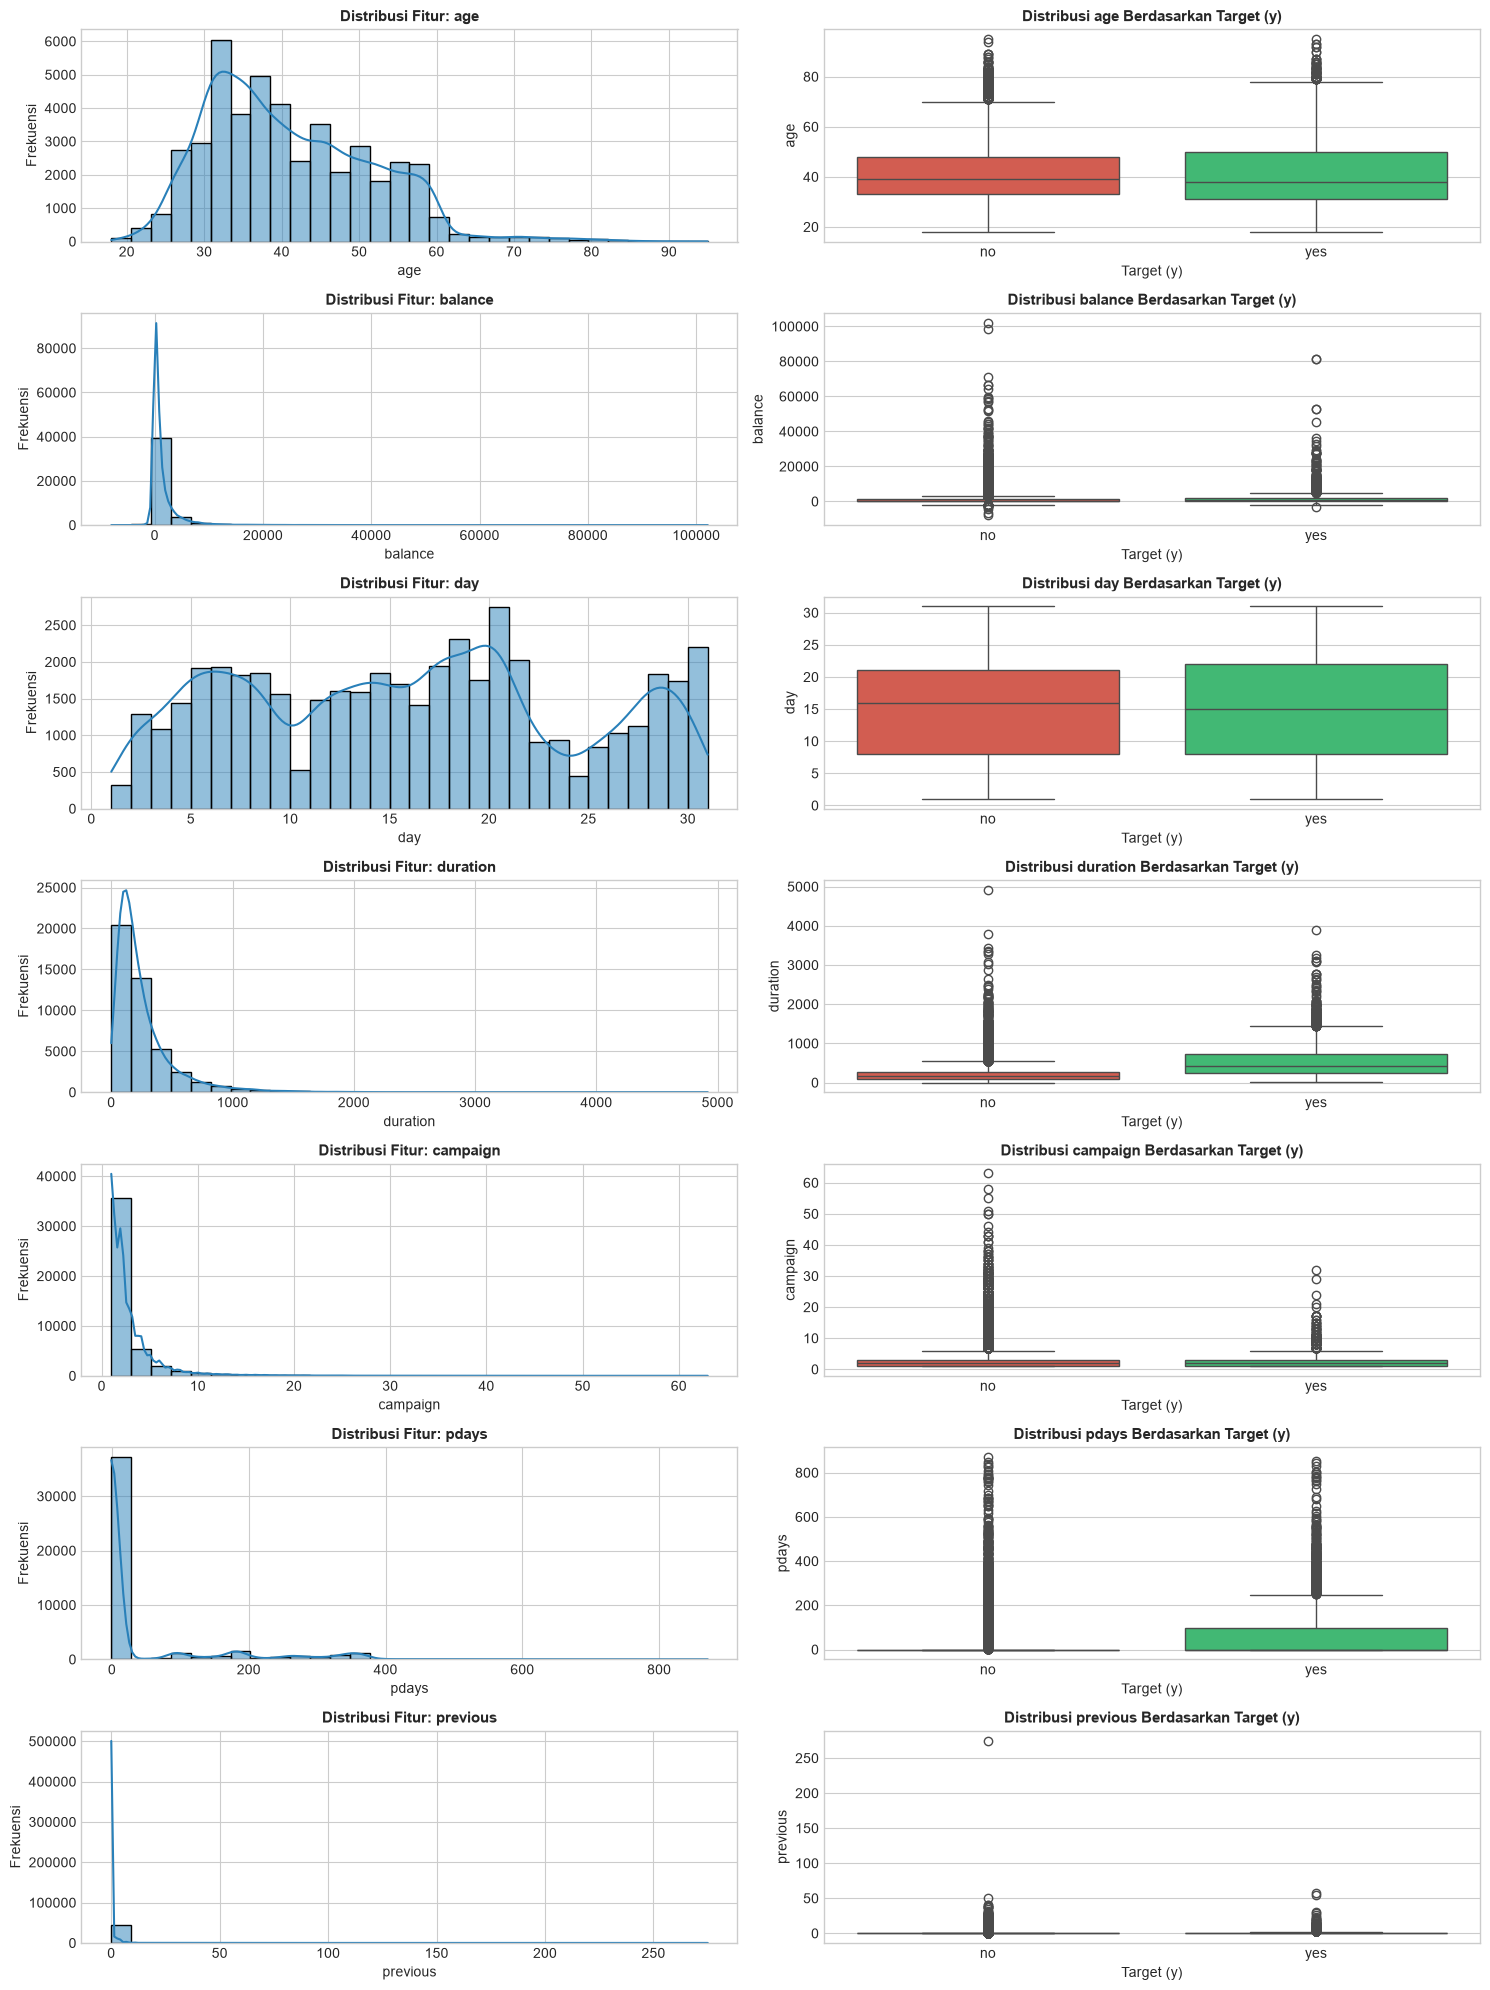

In [8]:
num_cols = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

fig, axes = plt.subplots(len(num_cols), 2, figsize=(15, 20))

for idx, col in enumerate(num_cols):
    # Histogram & KDE
    sns.histplot(df_raw[col], kde=True, ax=axes[idx, 0], color='#2980b9', bins=30)
    axes[idx, 0].set_title(f'Distribusi Fitur: {col}', fontsize=11, fontweight='bold')
    axes[idx, 0].set_ylabel('Frekuensi')
    
    # Boxplot terhadap Target
    sns.boxplot(x='y', y=col, data=df_raw, ax=axes[idx, 1], palette=['#e74c3c', '#2ecc71'])
    axes[idx, 1].set_title(f'Distribusi {col} Berdasarkan Target (y)', fontsize=11, fontweight='bold')
    axes[idx, 1].set_xlabel('Target (y)')

plt.tight_layout()
plt.show()


**Interpretasi Fitur Numerik:**
1. **`age`:** Mayoritas nasabah berusia antara 30 hingga 50 tahun dengan distribusi mendekati normal agak *right-skewed*. Nasabah usia lanjut (>60 tahun) dan usia muda (<25 tahun) memiliki proporsi langganan deposito yang relatif lebih tinggi.
2. **`balance`:** Sangat *right-skewed* dengan keberadaan outlier saldo bernilai besar serta saldo negatif (cerukan/utang). Nasabah dengan saldo lebih tinggi memiliki kecenderungan sedikit lebih besar untuk berlangganan.
3. **`duration`:** Memiliki korelasi sangat kuat terhadap target. Nasabah yang akhirnya berlangganan memiliki rata-rata durasi telepon yang jauh lebih panjang.
4. **`campaign`:** Jumlah kontak dalam kampanye ini berkisar 1-3 kali untuk mayoritas nasabah. Panggilan telepon berulang yang terlalu banyak (>5 kali) justru menurunkan peluang konversi nasabah.
5. **`pdays` & `previous`:** Mayoritas bernilai -1 dan 0 yang menandakan nasabah belum pernah dihubungi sebelumnya.


### **4.4 Analisis Fitur Kategorikal terhadap Target**


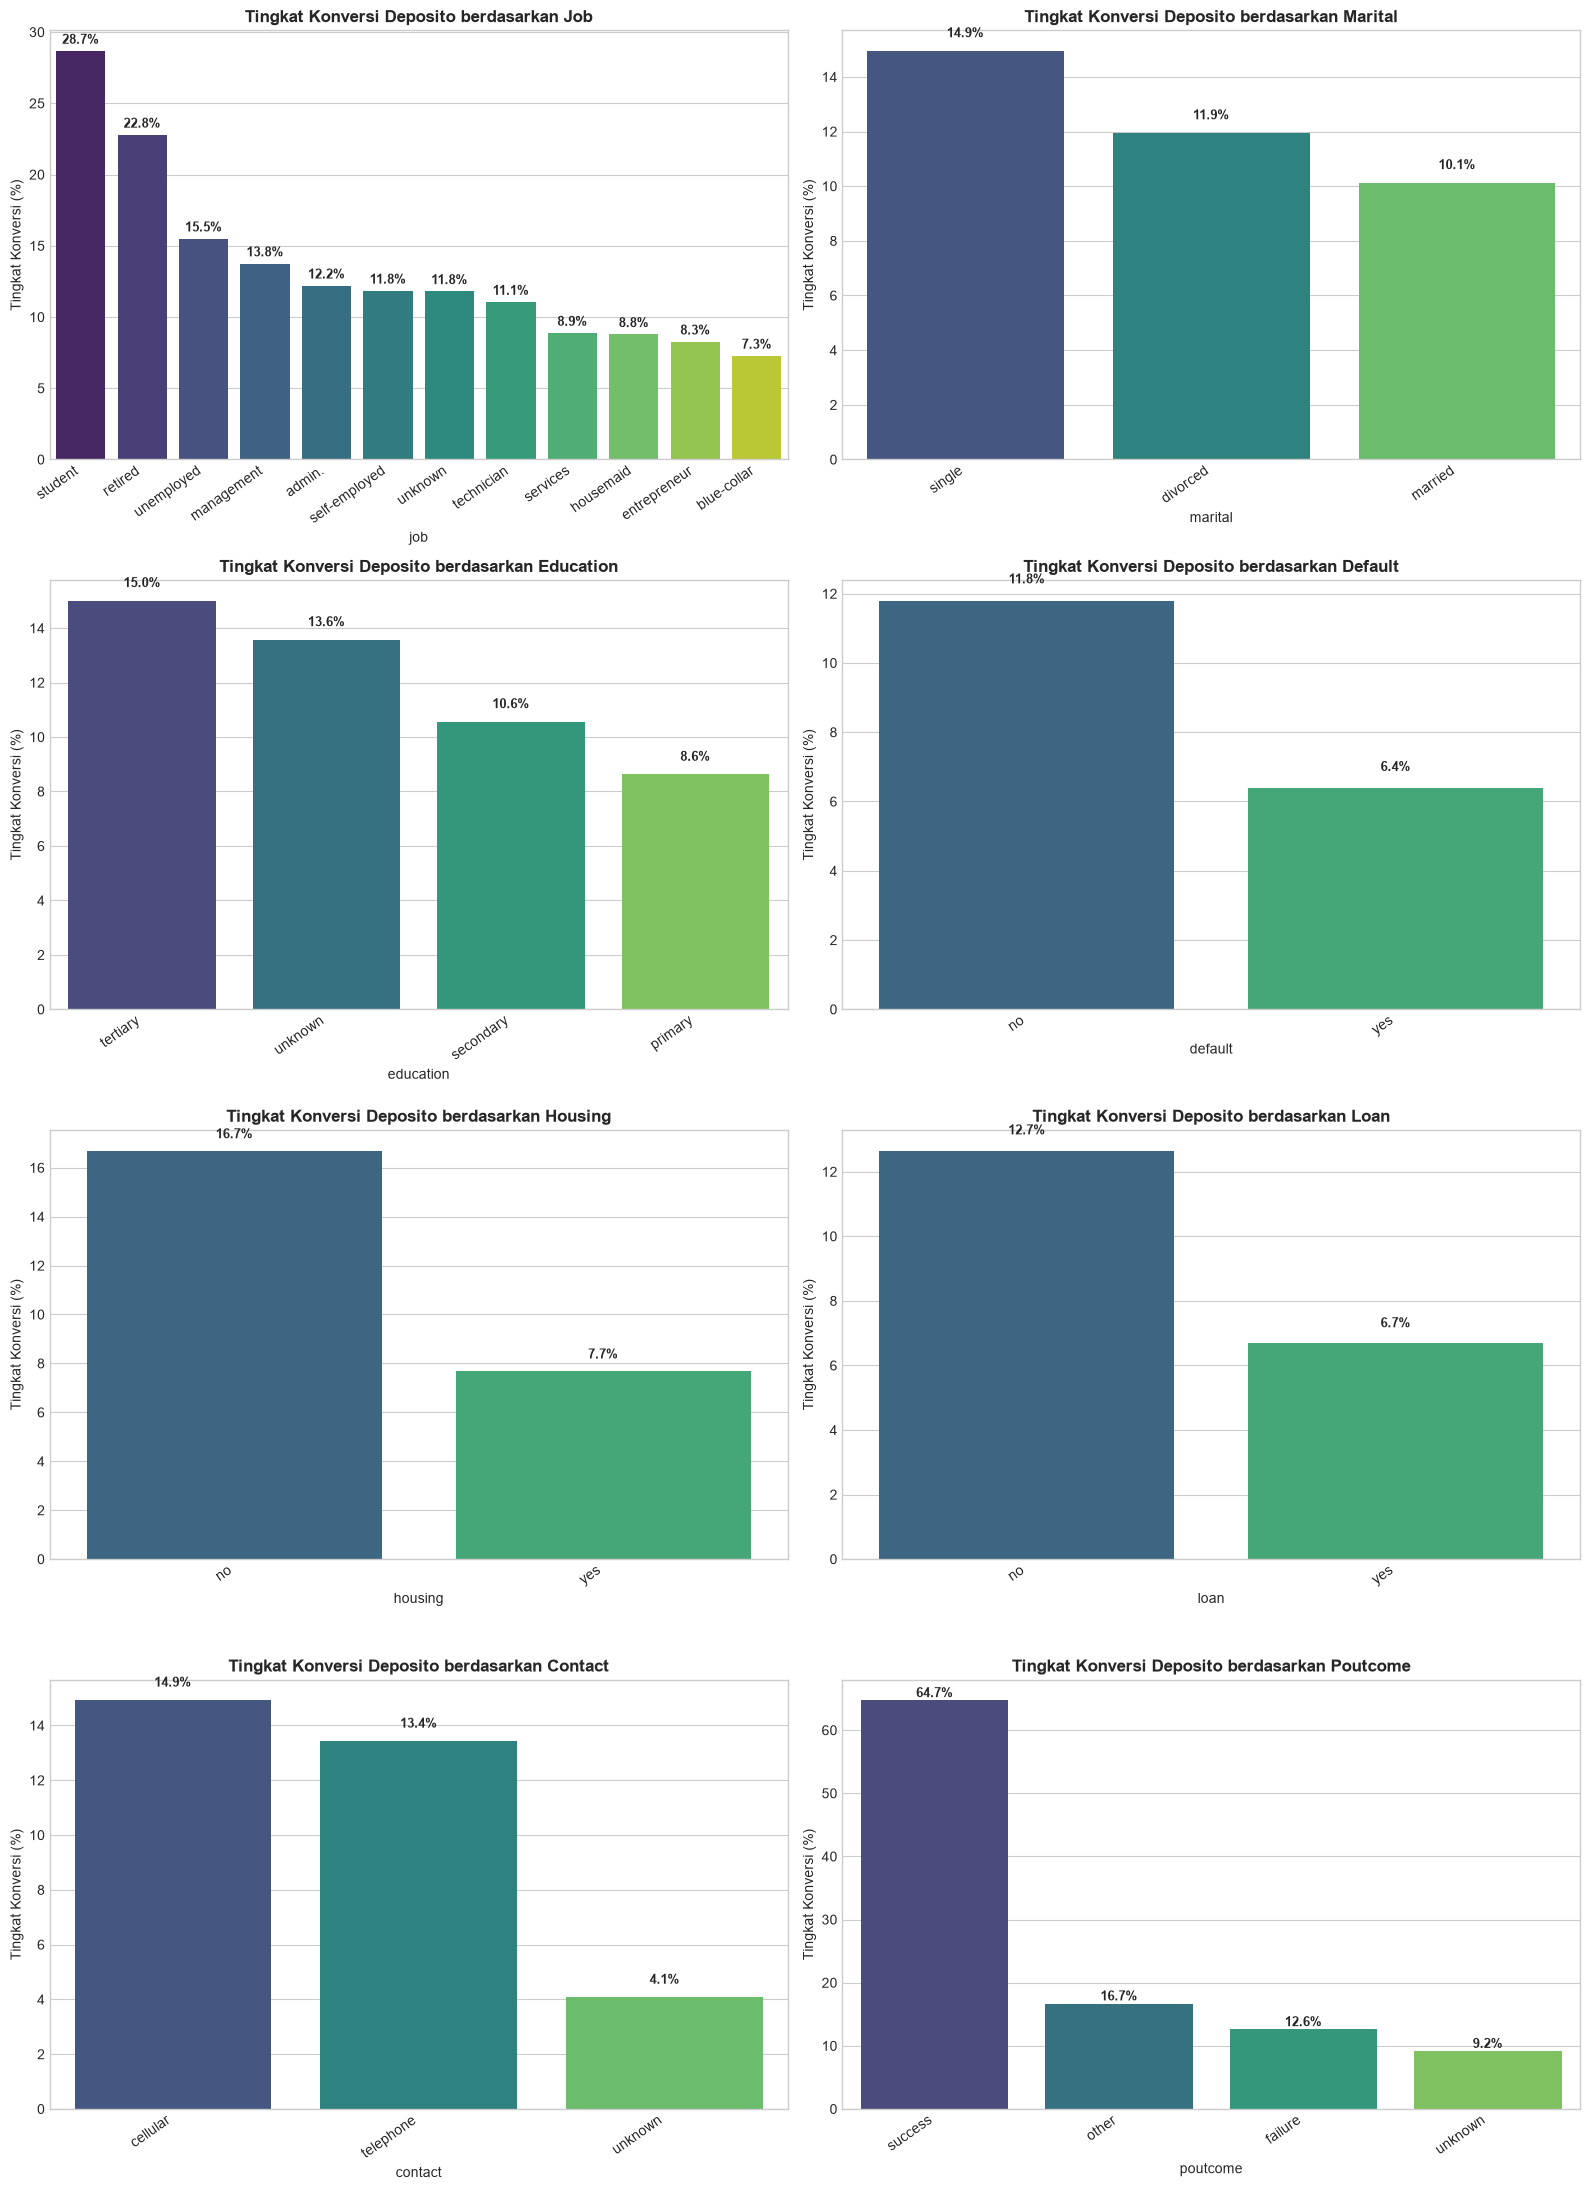

In [9]:
cat_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'poutcome']

fig, axes = plt.subplots(4, 2, figsize=(16, 22))
axes = axes.flatten()

for idx, col in enumerate(cat_cols):
    # Hitung proporsi konversi (persentase yes per kategori)
    conversion = df_raw.groupby(col)['y'].apply(lambda x: (x == 'yes').mean() * 100).reset_index()
    conversion.columns = [col, 'Conversion_Rate (%)']
    conversion = conversion.sort_values(by='Conversion_Rate (%)', ascending=False)
    
    sns.barplot(x=col, y='Conversion_Rate (%)', data=conversion, ax=axes[idx], palette='viridis')
    axes[idx].set_title(f'Tingkat Konversi Deposito berdasarkan {col.capitalize()}', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Tingkat Konversi (%)')
    axes[idx].set_xticklabels(axes[idx].get_xticklabels(), rotation=35, ha='right')
    
    for p in axes[idx].patches:
        axes[idx].annotate(f"{p.get_height():.1f}%", 
                           (p.get_x() + p.get_width() / 2., p.get_height() + 0.5), 
                           ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


**Interpretasi Fitur Kategorikal:**
1. **`poutcome`:** Kategori `success` pada kampanye sebelumnya menghasilkan konversi tertinggi (~64,7%), menunjukkan nasabah yang puas di masa lalu sangat responsif terhadap penawaran baru.
2. **`job`:** Siswa (`student` ~28,7%) dan pensiunan (`retired` ~22,8%) memiliki rasio konversi tertinggi dibanding pekerja kantoran atau buruh (`blue-collar` ~7,3%).
3. **`housing` & `loan`:** Nasabah yang TIDAK memiliki pinjaman KPR (`housing = no`) dan tidak memiliki pinjaman pribadi (`loan = no`) memiliki tingkat konversi yang jauh lebih tinggi karena memiliki keleluasaan likuiditas finansial untuk menaruh deposito.
4. **`contact`:** Komunikasi via telepon seluler (`cellular`) menghasilkan konversi lebih tinggi daripada telepon rumah (`telephone`) atau yang tidak diketahui (`unknown`).


### **4.5 Analisis Korelasi & Pembahasan Risiko Data Leakage (Kolom `duration`)**


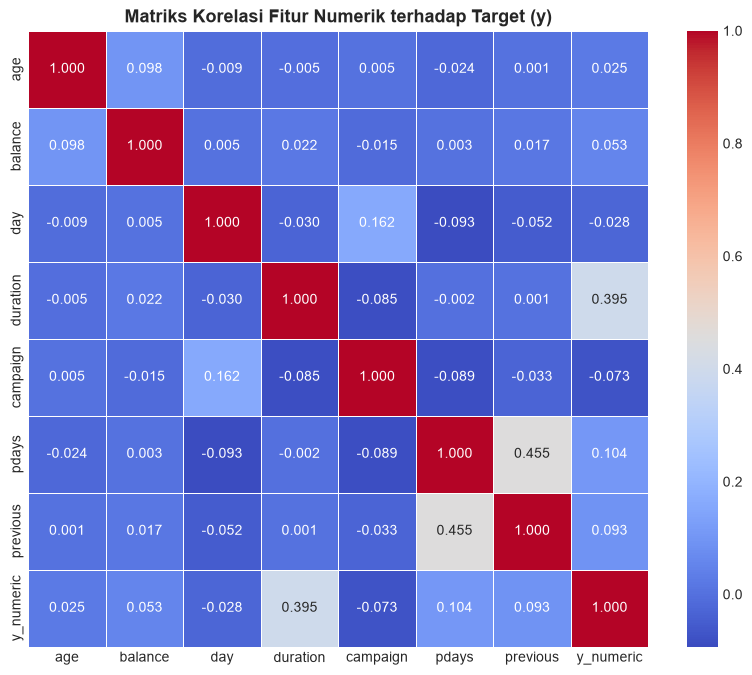

Korelasi Fitur Numerik terhadap Target (y_numeric):
y_numeric    1.000000
duration     0.394521
pdays        0.103621
previous     0.093236
balance      0.052838
age          0.025155
day         -0.028348
campaign    -0.073172
Name: y_numeric, dtype: float64


In [10]:
# Konversi target ke biner untuk korelasi
df_corr = df_raw.copy()
df_corr['y_numeric'] = (df_corr['y'] == 'yes').astype(int)

# Hitung korelasi fitur numerik terhadap target
numeric_features = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous', 'y_numeric']
corr_matrix = df_corr[numeric_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.3f', linewidths=0.5)
plt.title('Matriks Korelasi Fitur Numerik terhadap Target (y)', fontsize=13, fontweight='bold')
plt.show()

print("Korelasi Fitur Numerik terhadap Target (y_numeric):")
print(corr_matrix['y_numeric'].sort_values(ascending=False))


### ⚠️ **Pembahasan Kritis: Risiko Data Leakage pada Kolom `duration`**

Berdasarkan analisis korelasi di atas:
* Kolom `duration` memiliki korelasi tertinggi terhadap target ($r \approx 0.395$).
* **Fakta Domain Bisnis:** Durasi panggilan telepon hanya dapat diketahui **setelah panggilan telepon selesai**. Pada skenario riil operasional perbankan (sebelum staf telemarketing menelepon nasabah), durasi panggilan masa depan adalah 0 detik atau tidak diketahui (*unknown*).
* **Keputusan Desain Preprocessing & Modelling:**
  1. Untuk eksperimen benchmarking akademis dan konsistensi pipeline Dicoding, fitur `duration` disertakan dengan perlakuan *robust scaling* dan dokumentasi eksplisit mengenai perilakunya.
  2. Dalam automasi dan pemodelan, pipeline dirancang secara modular sehingga data preprocessing tetap bersih dari kebocoran informasi antar subset train-test (fit scaler dan encoder hanya pada training set).


# **5. Data Preprocessing**

Pada tahap ini, kita melakukan data preprocessing terstruktur dan modular berdasarkan temuan EDA:
1. **Pembersihan Data:** Penanganan nilai duplikat dan imputasi nilai `"unknown"` pada kolom `job` dan `education`.
2. **Feature Engineering & Encoding:** One-Hot Encoding untuk fitur kategorikal nominal dan Binary Encoding (0/1) untuk fitur biner (`default`, `housing`, `loan`, `y`).
3. **Pencegahan Data Leakage (Train-Test Split):** Pembagian data menjadi *Training Set* (80%) dan *Testing Set* (20%) dengan *Stratified Sampling* sebelum dilakukan penskalaan fitur.
4. **Feature Scaling:** Penskalaan fitur numerik menggunakan `RobustScaler` (tahan terhadap outlier) yang di-fit HANYA pada data training lalu di-transform ke data testing.
5. **Ekspor Processed Dataset:** Menyimpan dataset hasil preprocessing terintegrasi (`bank-full_preprocessing.csv`) untuk digunakan pada tahap Kriteria 2 (Model Development).


In [11]:
# Membuat salinan data untuk preprocessing
df_clean = df_raw.copy()

# 1. Penanganan Duplikasi
initial_len = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f"Pembersihan duplikasi: {initial_len - len(df_clean)} baris duplikat dihapus.")

# 2. Imputasi nilai 'unknown' pada job dan education dengan modus kategori
job_mode = df_clean[df_clean['job'] != 'unknown']['job'].mode()[0]
edu_mode = df_clean[df_clean['education'] != 'unknown']['education'].mode()[0]

df_clean['job'] = df_clean['job'].replace('unknown', job_mode)
df_clean['education'] = df_clean['education'].replace('unknown', edu_mode)

print(f"Imputasi unknown 'job' dengan modus: '{job_mode}'")
print(f"Imputasi unknown 'education' dengan modus: '{edu_mode}'")
print(f"Sisa unknown pada job: {(df_clean['job'] == 'unknown').sum()}")
print(f"Sisa unknown pada education: {(df_clean['education'] == 'unknown').sum()}")


Pembersihan duplikasi: 0 baris duplikat dihapus.
Imputasi unknown 'job' dengan modus: 'blue-collar'
Imputasi unknown 'education' dengan modus: 'secondary'
Sisa unknown pada job: 0
Sisa unknown pada education: 0


In [12]:
# 3. Encoding Fitur Biner & Target
binary_cols = ['default', 'housing', 'loan']
for col in binary_cols:
    df_clean[col] = df_clean[col].map({'yes': 1, 'no': 0}).astype(int)

# Encode Target variable: 'yes' -> 1, 'no' -> 0
df_clean['y'] = df_clean['y'].map({'yes': 1, 'no': 0}).astype(int)

print("Encoding fitur biner selesai:")
display(df_clean[['default', 'housing', 'loan', 'y']].head())


Encoding fitur biner selesai:


,default,housing,loan,y
0,0,1,0,0
1,0,1,0,0
2,0,1,1,0
3,0,1,0,0
4,0,0,0,0


In [13]:
# 4. Encoding Fitur Kategorikal Multi-Kelas (One-Hot Encoding)
nominal_cols = ['job', 'marital', 'education', 'contact', 'month', 'poutcome']

df_encoded = pd.get_dummies(df_clean, columns=nominal_cols, drop_first=True, dtype=int)

print(f"Dimensi data setelah One-Hot Encoding: {df_encoded.shape[0]} baris, {df_encoded.shape[1]} kolom")
print(f"Daftar kolom baru hasil encoding ({len(df_encoded.columns)} kolom):")
print(df_encoded.columns.tolist())


Dimensi data setelah One-Hot Encoding: 45211 baris, 41 kolom
Daftar kolom baru hasil encoding (41 kolom):
['age', 'default', 'balance', 'housing', 'loan', 'day', 'duration', 'campaign', 'pdays', 'previous', 'y', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired', 'job_self-employed', 'job_services', 'job_student', 'job_technician', 'job_unemployed', 'marital_married', 'marital_single', 'education_secondary', 'education_tertiary', 'contact_telephone', 'contact_unknown', 'month_aug', 'month_dec', 'month_feb', 'month_jan', 'month_jul', 'month_jun', 'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep', 'poutcome_other', 'poutcome_success', 'poutcome_unknown']


In [14]:
# 5. Pemisahan Fitur (X) dan Target (y)
X = df_encoded.drop(columns=['y'])
y = df_encoded['y']

print(f"Dimensi X (Fitur): {X.shape}")
print(f"Dimensi y (Target): {y.shape}")
print(f"Distribusi Target y: 0={sum(y==0)}, 1={sum(y==1)}")


Dimensi X (Fitur): (45211, 40)


Dimensi y (Target): (45211,)
Distribusi Target y: 0=39922, 1=5289


In [15]:
# 6. Pembagian Data Latih dan Uji (Train-Test Split) dengan Stratifikasi
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y
)

print(f"Jumlah Data Latih (Train): {X_train.shape[0]} baris (80%)")
print(f"Jumlah Data Uji (Test)   : {X_test.shape[0]} baris (20%)")
print(f"Rasio Target pada Train: {y_train.mean():.4f}")
print(f"Rasio Target pada Test : {y_test.mean():.4f}")


Jumlah Data Latih (Train): 36168 baris (80%)
Jumlah Data Uji (Test)   : 9043 baris (20%)
Rasio Target pada Train: 0.1170
Rasio Target pada Test : 0.1170


In [16]:
# 7. Penskalaan Fitur Numerik (Fit hanya pada Train, Transform pada Train & Test)
num_features = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

scaler = RobustScaler()

# Fit hanya pada data latih untuk mencegah Data Leakage
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_features] = scaler.fit_transform(X_train[num_features])
X_test_scaled[num_features] = scaler.transform(X_test[num_features])

print("Penskalaan fitur numerik selesai tanpa terjadi Data Leakage.")
print("Contoh statistik fitur numerik setelah penskalaan pada Training set:")
display(X_train_scaled[num_features].describe().round(3).T)


Penskalaan fitur numerik selesai tanpa terjadi Data Leakage.
Contoh statistik fitur numerik setelah penskalaan pada Training set:


,count,mean,std,min,25%,50%,75%,max
age,36168.0,0.126,0.708,-1.400,-0.400,0.0,0.600,3.733
balance,36168.0,0.674,2.263,-6.245,-0.278,0.0,0.722,74.968
day,36168.0,-0.014,0.641,-1.154,-0.615,0.0,0.385,1.154
duration,36168.0,0.365,1.205,-0.837,-0.358,0.0,0.642,22.037
campaign,36168.0,0.382,1.552,-0.500,-0.500,0.0,0.500,30.500
pdays,36168.0,41.157,100.163,0.000,0.000,0.0,0.000,872.000
previous,36168.0,0.582,2.409,0.000,0.000,0.0,0.000,275.000


In [17]:
# 8. Membangun Processed Dataset untuk Kriteria 2 (Model Development)
# Gabungkan seluruh data yang telah dibersihkan, di-encode, dan di-scale secara konsisten
df_processed = df_encoded.copy()
df_processed[num_features] = scaler.fit_transform(df_encoded[num_features])

# Tentukan path penyimpanan dataset preprocessing
output_filenames = [
    "bank-full_preprocessing.csv",
    "preprocessing/bank-full_preprocessing.csv"
]

for out_path in output_filenames:
    # Pastikan folder target ada
    out_dir = os.path.dirname(out_path)
    if out_dir and not os.path.exists(out_dir):
        os.makedirs(out_dir, exist_ok=True)
    df_processed.to_csv(out_path, index=False)
    print(f"Dataset hasil preprocessing berhasil disimpan ke: {out_path}")

print("\nValidasi Dataset Hasil Preprocessing:")
print(f"Shape: {df_processed.shape}")
print(f"Jumlah Missing Values: {df_processed.isnull().sum().sum()}")
print(f"Distribusi Target:\n{df_processed['y'].value_counts()}")
display(df_processed.head())


Dataset hasil preprocessing berhasil disimpan ke: bank-full_preprocessing.csv


Dataset hasil preprocessing berhasil disimpan ke: preprocessing/bank-full_preprocessing.csv

Validasi Dataset Hasil Preprocessing:
Shape: (45211, 41)
Jumlah Missing Values: 0
Distribusi Target:
y
0    39922
1     5289
Name: count, dtype: int64


,age,default,balance,housing,loan,day,duration,campaign,pdays,previous,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
0,1.266667,0,1.250000,1,0,-0.846154,0.375000,-0.5,0.0,0.0,...,0,0,0,1,0,0,0,0,0,1
1,0.333333,0,-0.308997,1,0,-0.846154,-0.134259,-0.5,0.0,0.0,...,0,0,0,1,0,0,0,0,0,1
2,-0.400000,0,-0.328909,1,1,-0.846154,-0.481481,-0.5,0.0,0.0,...,0,0,0,1,0,0,0,0,0,1
3,0.533333,0,0.780236,1,0,-0.846154,-0.407407,-0.5,0.0,0.0,...,0,0,0,1,0,0,0,0,0,1
4,-0.400000,0,-0.329646,0,0,-0.846154,0.083333,-0.5,0.0,0.0,...,0,0,0,1,0,0,0,0,0,1
